In [94]:
cwe_stats = "../dataset_test/data/"
import os
import pandas as pd
original_df = pd.DataFrame(columns=[
    "cwe",
    'additions',
    'deletions',
])
for file in os.listdir(cwe_stats):
    if file.endswith(".jsonl") and file not in ["NVD-CWE-Other.jsonl"]:
        with open(cwe_stats + "/" + file, "r") as f:
            lines = f.readlines()
            import json
            for line in lines:
                data = json.loads(line)
                cwe = data["cwe"]
                additions = data["additions"]
                deletions = data["deletions"]
                

                # Store the results in a dataframe
                results = pd.DataFrame({
                    "cwe": cwe,
                    'additions': [additions],
                    'deletions': [deletions],
                })
                
                original_df = pd.concat([original_df, results], ignore_index=True)
                

    
                
# Ensure additions and deletions are integers
original_df["additions"] = original_df["additions"].astype(int)
original_df["deletions"] = original_df["deletions"].astype(int)


In [95]:
# Filter out cwe that have less than 20 rows
original_df = original_df.groupby("cwe").filter(lambda x: len(x) >= 20)
original_df

,cwe,additions,deletions
28,CWE-74,6,1
29,CWE-74,6,1
30,CWE-74,1,1
31,CWE-74,1,1
32,CWE-74,8,1
...,...,...,...
1814,CWE-476,3,0
1815,CWE-476,2,0
1816,CWE-476,2,0
1817,CWE-476,34,33


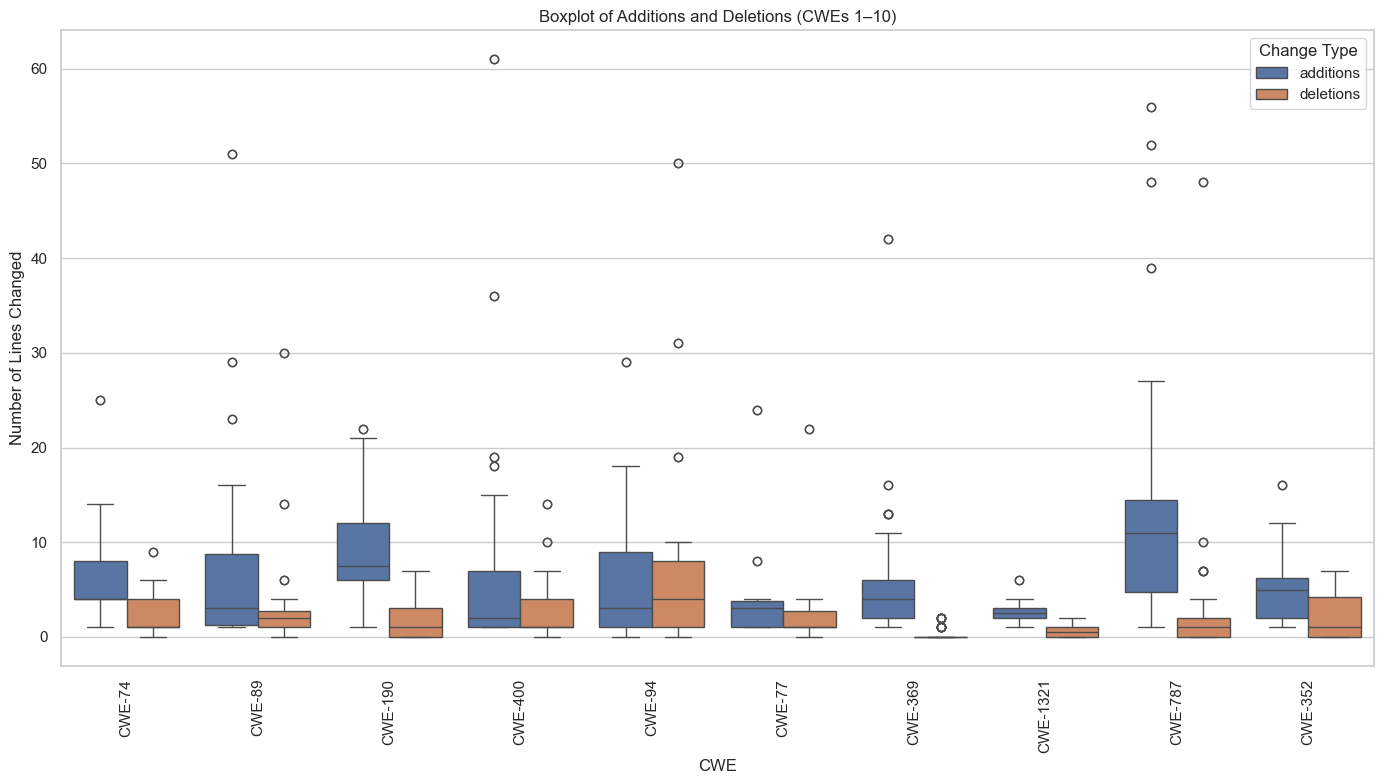

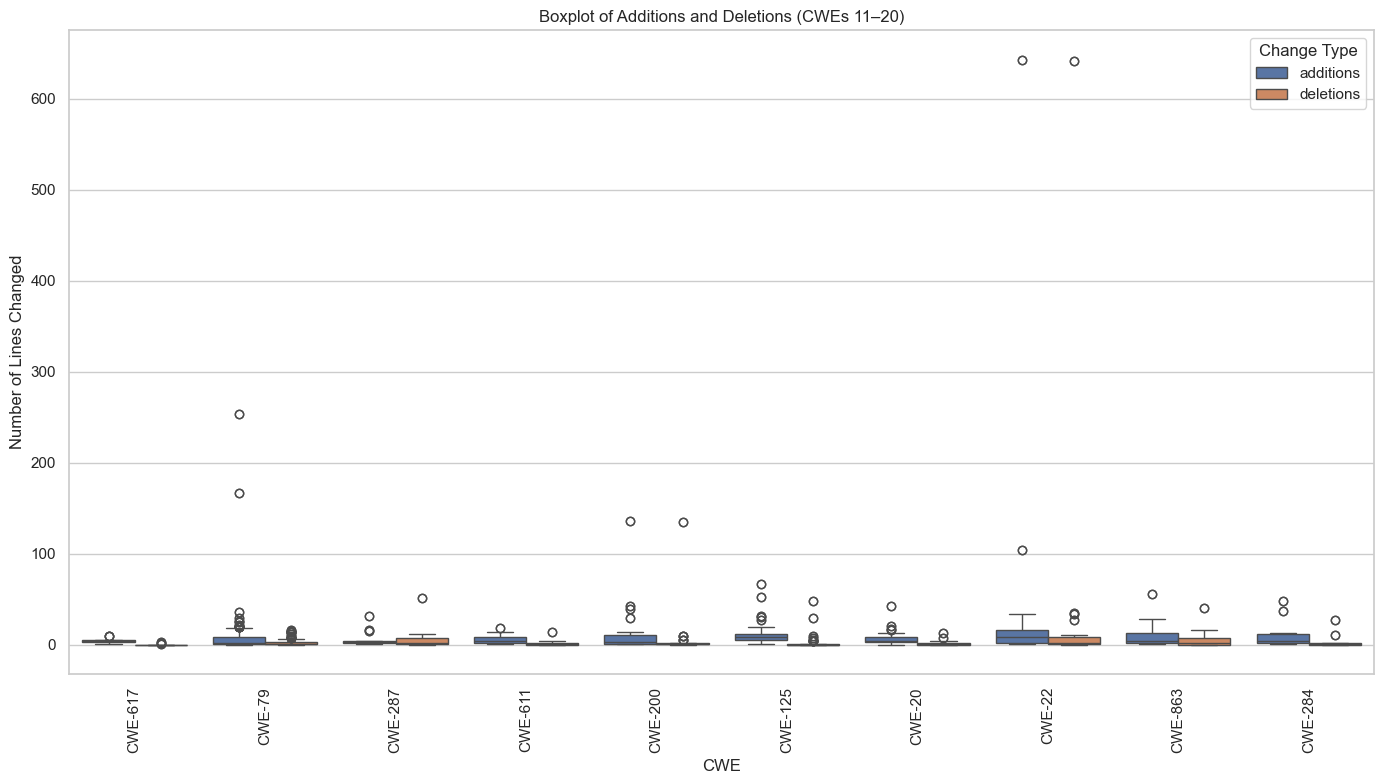

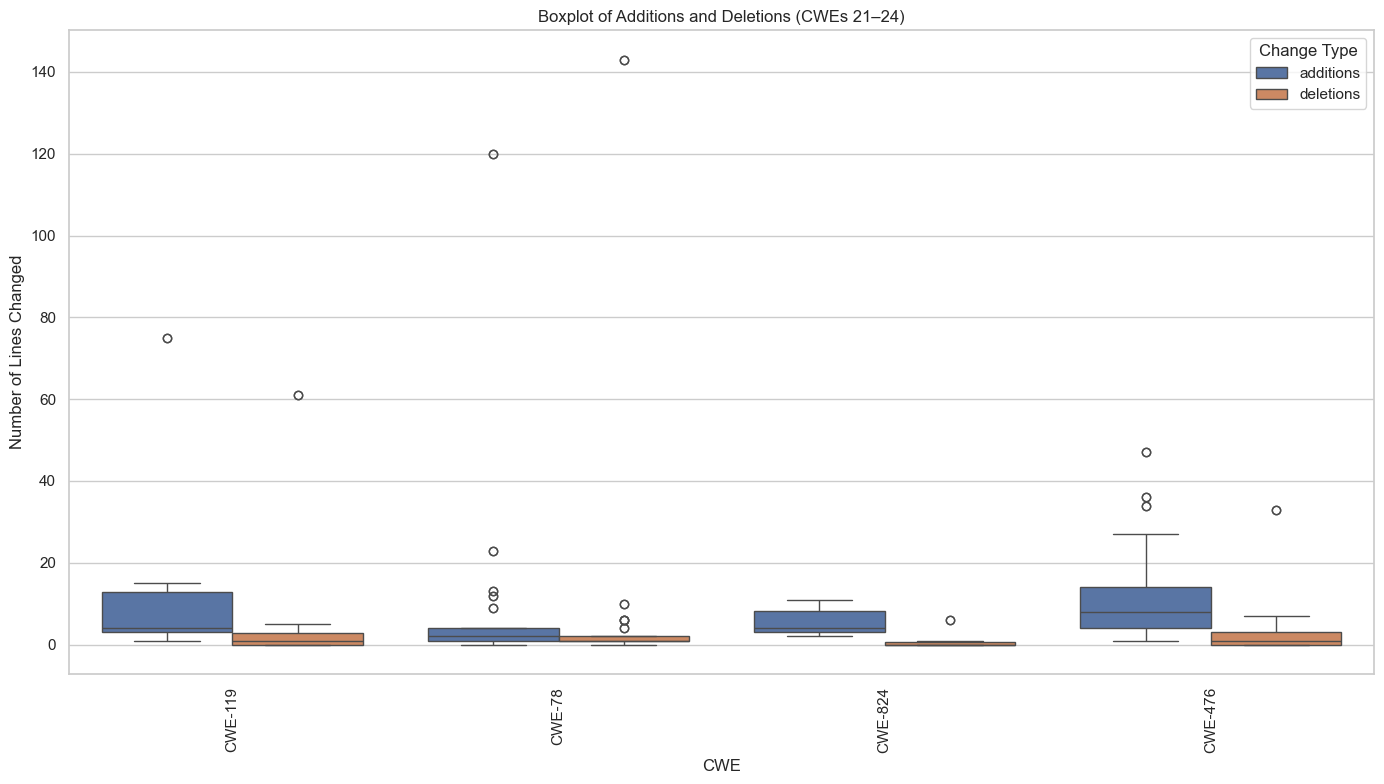

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure correct types
original_df["additions"] = original_df["additions"].astype(int)
original_df["deletions"] = original_df["deletions"].astype(int)

# Melt the DataFrame to long-form
melted_df = original_df.melt(id_vars=["cwe"], value_vars=["additions", "deletions"],
                    var_name="Change Type", value_name="Lines Changed")

# Get unique CWEs in chunks of 10
unique_cwes = melted_df["cwe"].unique()
chunk_size = 10

for i in range(0, len(unique_cwes), chunk_size):
    cwe_chunk = unique_cwes[i:i + chunk_size]
    chunk_df = melted_df[melted_df["cwe"].isin(cwe_chunk)]

    # Plot
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=chunk_df, x="cwe", y="Lines Changed", hue="Change Type")
    plt.title(f"Boxplot of Additions and Deletions (CWEs {i + 1}–{i + len(cwe_chunk)})")
    plt.xlabel("CWE")
    plt.ylabel("Number of Lines Changed")
    plt.xticks(rotation=90)
    plt.legend(title="Change Type")
    plt.tight_layout()
    plt.show()


In [97]:
mean_additions = original_df.groupby("cwe")["additions"].mean()
mean_deletions = original_df.groupby("cwe")["deletions"].mean()

# create a dictionary such as 
#cwe_line_changes = {
#    'CWE-79': {'added': 120, 'deleted': 85},

cwe_line_changes = {}
for cwe in original_df["cwe"].unique():
    cwe_line_changes[cwe] = {
        'added': int(mean_additions[cwe]),
        'deleted': int(mean_deletions[cwe])
    }
print(cwe_line_changes)

{'CWE-74': {'added': 6, 'deleted': 2}, 'CWE-89': {'added': 8, 'deleted': 3}, 'CWE-190': {'added': 9, 'deleted': 2}, 'CWE-400': {'added': 6, 'deleted': 2}, 'CWE-94': {'added': 6, 'deleted': 7}, 'CWE-77': {'added': 4, 'deleted': 3}, 'CWE-369': {'added': 5, 'deleted': 0}, 'CWE-1321': {'added': 2, 'deleted': 0}, 'CWE-787': {'added': 14, 'deleted': 3}, 'CWE-352': {'added': 5, 'deleted': 2}, 'CWE-617': {'added': 4, 'deleted': 0}, 'CWE-79': {'added': 8, 'deleted': 2}, 'CWE-287': {'added': 6, 'deleted': 7}, 'CWE-611': {'added': 5, 'deleted': 1}, 'CWE-200': {'added': 14, 'deleted': 7}, 'CWE-125': {'added': 11, 'deleted': 3}, 'CWE-20': {'added': 6, 'deleted': 1}, 'CWE-22': {'added': 37, 'deleted': 30}, 'CWE-863': {'added': 10, 'deleted': 6}, 'CWE-284': {'added': 11, 'deleted': 4}, 'CWE-119': {'added': 11, 'deleted': 5}, 'CWE-78': {'added': 9, 'deleted': 8}, 'CWE-824': {'added': 5, 'deleted': 0}, 'CWE-476': {'added': 11, 'deleted': 2}}


In [98]:
folder_path = "../results_osv_/"

In [99]:
import os
import pandas as pd
df = pd.DataFrame(columns=[
    "model",
    "cwe",
    "iqr",
    "mean",
    "median",
    "min",
    "max",
    "perplexity"
])
for file in os.listdir(folder_path):
    if file.endswith(".jsonl") and file not in ["NVD-CWE-Other.jsonl"]:
        with open(folder_path + "/" + file, "r") as f:
            lines = f.readlines()
            import json
            for line in lines:
                data = json.loads(line)
                # {"cwe": "CWE-16", "model": "openai-community/gpt2", "vulnerable": [1717.9267578125], "safe": [372.79498291015625]}
                model = data["model"]
                cwe = data["cwe"]
                vulnerable = data["vulnerable"]
                safe = data["safe"]
                # compute the IQR
                import numpy as np
                vulnerable = np.array(vulnerable)
                safe = np.array(safe)
                iqr_vulnerable = np.percentile(vulnerable, 75) - np.percentile(vulnerable, 25)
                iqr_safe = np.percentile(safe, 75) - np.percentile(safe, 25)

                # compute the mean
                mean_vulnerable = np.mean(vulnerable)
                mean_safe = np.mean(safe)

                # compute the median
                median_vulnerable = np.median(vulnerable)
                median_safe = np.median(safe)

                # compute the min
                min_vulnerable = np.min(vulnerable)
                min_safe = np.min(safe)

                # compute the max
                max_vulnerable = np.max(vulnerable)
                max_safe = np.max(safe)

                # Store the results in a dataframe
                results_vulnerable = pd.DataFrame({
                    "model": [model],
                    "cwe": [cwe],
                    "iqr": [iqr_vulnerable],
                    "mean": [mean_vulnerable],
                    "median": [median_vulnerable],
                    "min": [min_vulnerable],
                    "max": [max_vulnerable],
                    "perplexity": [vulnerable]
                })
                results_safe = pd.DataFrame({
                    "model": [model],
                    "cwe": [cwe+" Patched"],
                    "iqr": [iqr_safe],
                    "mean": [mean_safe],
                    "median": [median_safe],
                    "min": [min_safe],
                    "max": [max_safe],
                    "perplexity": [safe]
                })
                
                df = pd.concat([df, results_vulnerable, results_safe], ignore_index=True)
                

    
                

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_48826/761664232.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, results_vulnerable, results_safe], ignore_index=True)


In [100]:
df["CWE_Number"] = df["cwe"].str.extract(r'(\d+)').astype(int)
df = df.sort_values(by=["CWE_Number", "model"])
print(df.shape)
# Filter rows where len(perplexity) < 20
df = df[df["perplexity"].apply(len) > 20]
print(df.shape)
df

(1088, 9)
(88, 9)


,model,cwe,iqr,mean,median,min,max,perplexity,CWE_Number
824,Salesforce/codegen-6B-multi,CWE-20,5.391602,8.675370,7.812500,3.150391,19.781250,"[7.5625, 3.373046875, 17.765625, 4.79296875, 3...",20
825,Salesforce/codegen-6B-multi,CWE-20 Patched,4.270508,6.966231,6.378906,1.849609,19.734375,"[6.6484375, 1.849609375, 9.4140625, 5.125, 2.9...",20
830,WizardLMTeam/WizardCoder-15B-V1.0,CWE-20,5.038811,7.974529,6.419022,2.898510,18.851521,"[5.676312446594238, 4.127105712890625, 16.1468...",20
831,WizardLMTeam/WizardCoder-15B-V1.0,CWE-20 Patched,3.961633,6.289383,5.024958,1.977169,29.143557,"[4.570919036865234, 1.9771692752838135, 6.3466...",20
826,lmsys/vicuna-13b-v1.5,CWE-20,9.530543,11.246099,10.045766,3.257356,27.211596,"[8.608431816101074, 5.8245530128479, 20.779743...",20
...,...,...,...,...,...,...,...,...,...
383,WizardLMTeam/WizardCoder-15B-V1.0,CWE-787 Patched,2.993287,4.414702,4.316406,1.379699,10.280654,"[1.6995002031326294, 5.869782447814941, 4.5514...",787
378,lmsys/vicuna-13b-v1.5,CWE-787,6.641174,9.954856,9.363178,2.987119,19.944811,"[3.4652557373046875, 10.527454376220703, 14.97...",787
379,lmsys/vicuna-13b-v1.5,CWE-787 Patched,4.123403,6.470623,5.584756,1.616881,17.206797,"[2.236443281173706, 10.931156158447266, 6.1887...",787
380,lmsys/vicuna-7b-v1.5,CWE-787,8.242589,11.202588,11.204769,3.055797,23.337641,"[4.060701847076416, 15.492602348327637, 17.805...",787


In [101]:
df["model"].value_counts()

model
Salesforce/codegen-6B-multi          22
WizardLMTeam/WizardCoder-15B-V1.0    22
lmsys/vicuna-13b-v1.5                22
lmsys/vicuna-7b-v1.5                 22
Name: count, dtype: int64

In [102]:
accpeted_models = [
    'Salesforce/codegen-6B-multi', 
    'WizardLMTeam/WizardCoder-15B-V1.0',
    'lmsys/vicuna-7b-v1.5', 
    "lmsys/vicuna-13b-v1.5",
    # 'Qwen/Qwen2.5-Coder-0.5B-Instruct',
    # 'deepseek-ai/deepseek-coder-6.7b-base',
    # 'meta-llama/CodeLlama-7b-hf', 
    # 'meta-llama/Llama-3.2-3B-Instruct'
]

prettier_names = {
    "openai-community/gpt2": "GPT-2",
    "microsoft/codebert-base": "CodeBERT",
    "WizardLMTeam/WizardCoder-15B-V1.0": "WizardCoder 15B",
    "Salesforce/codegen-6B-multi": "Codegen 6B",
    "lmsys/vicuna-7b-v1.5": "Vicuna 7B",
    "lmsys/vicuna-13b-v1.5": "Vicuna 13B",
    "Qwen/Qwen2.5-Coder-0.5B-Instruct": "Qwen 0.5B",
    "deepseek-ai/deepseek-coder-6.7b-base": "Deepseek 6.7B",
    "meta-llama/CodeLlama-7b-hf": "CodeLlama 7B",
    "meta-llama/Llama-3.2-3B-Instruct": "Llama 3.2B"
}


df = df[df["model"].isin(accpeted_models)]
df

,model,cwe,iqr,mean,median,min,max,perplexity,CWE_Number
824,Salesforce/codegen-6B-multi,CWE-20,5.391602,8.675370,7.812500,3.150391,19.781250,"[7.5625, 3.373046875, 17.765625, 4.79296875, 3...",20
825,Salesforce/codegen-6B-multi,CWE-20 Patched,4.270508,6.966231,6.378906,1.849609,19.734375,"[6.6484375, 1.849609375, 9.4140625, 5.125, 2.9...",20
830,WizardLMTeam/WizardCoder-15B-V1.0,CWE-20,5.038811,7.974529,6.419022,2.898510,18.851521,"[5.676312446594238, 4.127105712890625, 16.1468...",20
831,WizardLMTeam/WizardCoder-15B-V1.0,CWE-20 Patched,3.961633,6.289383,5.024958,1.977169,29.143557,"[4.570919036865234, 1.9771692752838135, 6.3466...",20
826,lmsys/vicuna-13b-v1.5,CWE-20,9.530543,11.246099,10.045766,3.257356,27.211596,"[8.608431816101074, 5.8245530128479, 20.779743...",20
...,...,...,...,...,...,...,...,...,...
383,WizardLMTeam/WizardCoder-15B-V1.0,CWE-787 Patched,2.993287,4.414702,4.316406,1.379699,10.280654,"[1.6995002031326294, 5.869782447814941, 4.5514...",787
378,lmsys/vicuna-13b-v1.5,CWE-787,6.641174,9.954856,9.363178,2.987119,19.944811,"[3.4652557373046875, 10.527454376220703, 14.97...",787
379,lmsys/vicuna-13b-v1.5,CWE-787 Patched,4.123403,6.470623,5.584756,1.616881,17.206797,"[2.236443281173706, 10.931156158447266, 6.1887...",787
380,lmsys/vicuna-7b-v1.5,CWE-787,8.242589,11.202588,11.204769,3.055797,23.337641,"[4.060701847076416, 15.492602348327637, 17.805...",787


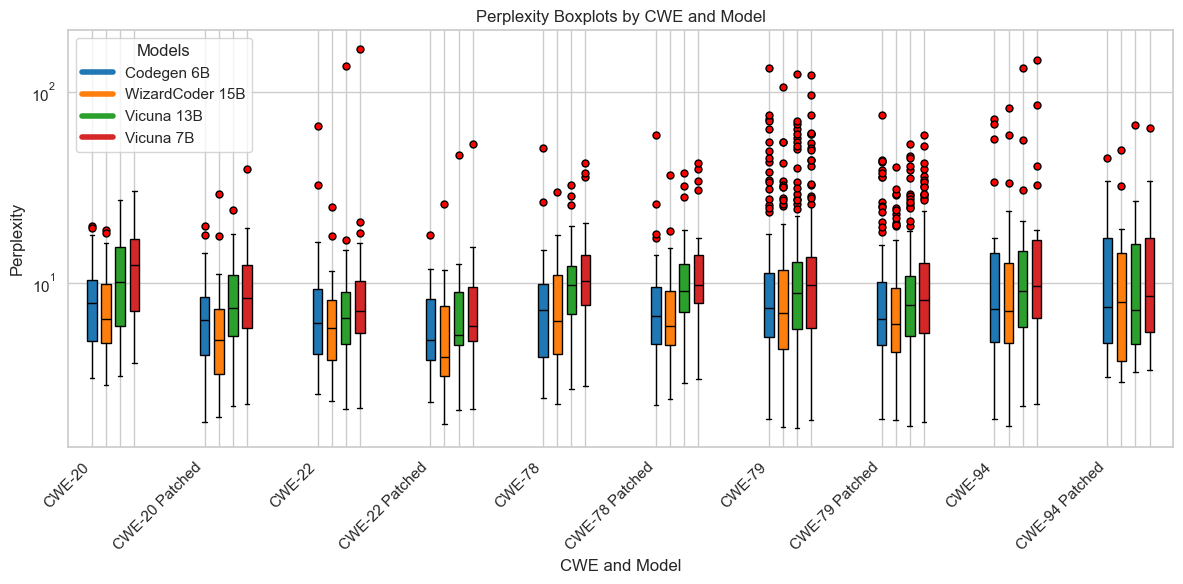

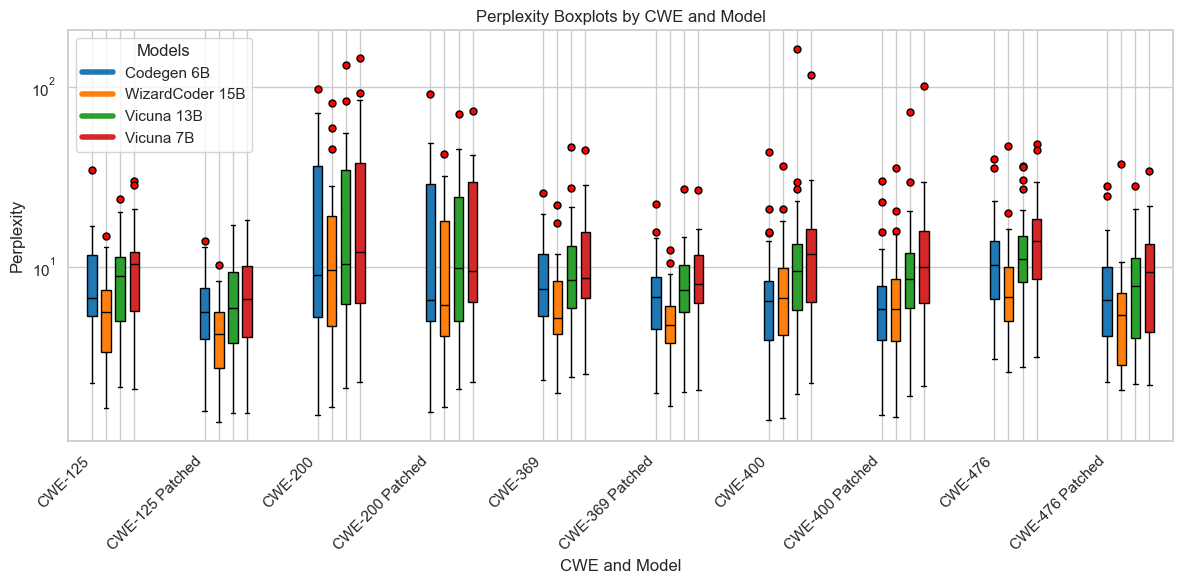

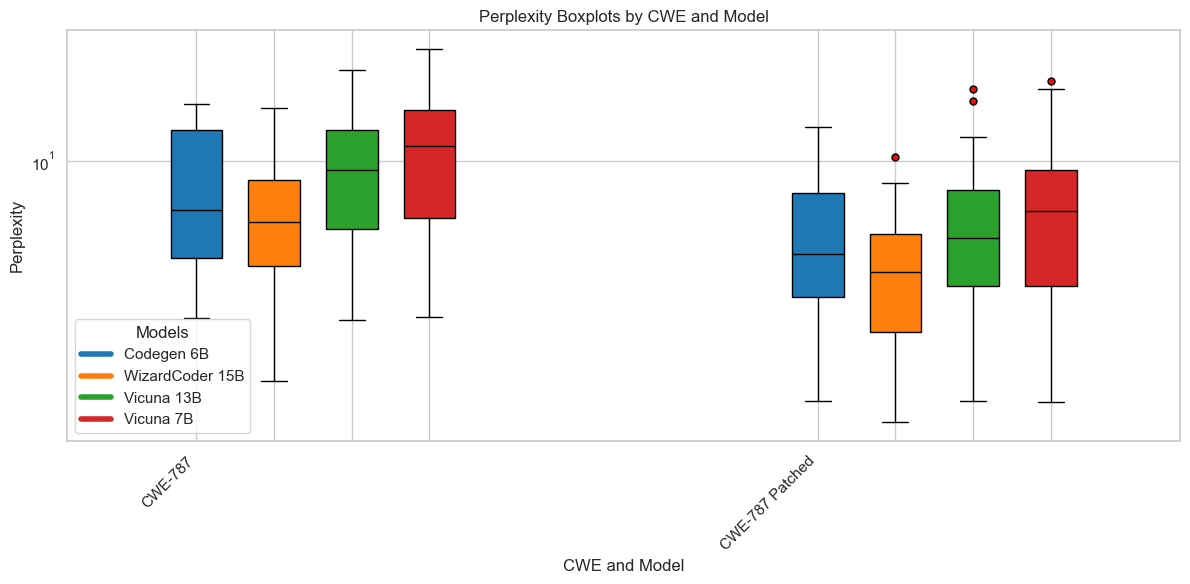

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

def plot_grouped_boxplots(df, cwe_subset, model_colors):
    plt.figure(figsize=(12, 6))
    
    # Filter data for selected CWEs
    subset_df = df[df["cwe"].isin(cwe_subset)]
    
    # Sort dataframe by CWE and model
    sorted_df = subset_df.sort_values(by=['cwe', 'model'])
    
    positions = []
    labels = []
    idx = 0
    cwe_spacing = 1.5  # Control spacing between different CWEs
    model_spacing = 0.3  # Control spacing between models under the same CWE

    legend_handles = {}  # To store legend handles
    
    # Grouping by CWE
    for cwe in sorted_df["cwe"].unique():
        cwe_df = sorted_df[sorted_df["cwe"] == cwe]
        cwe_base_idx = idx
        
        for j, model in enumerate(cwe_df["model"].unique()):
            model_df = cwe_df[cwe_df["model"] == model]
            pos = cwe_base_idx + j * model_spacing

            # print("----")
            # print(cwe)
            # print(len(model_df["perplexity"]))
            # print(model_df["perplexity"])
            # print(model)
            # Create boxplot and capture its elements
            box = plt.boxplot(
                model_df["perplexity"],
                positions=[pos],
                widths=0.2,
                patch_artist=True,
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, markerfacecolor="red"),
            )
            
            # Color the boxes appropriately
            for b in box['boxes']:
                b.set_facecolor(model_colors[model])

            # Store legend info
            if model not in legend_handles:
                legend_handles[model] = plt.Line2D([0], [0], color=model_colors[model], lw=4, label=prettier_names[model])

            if cwe not in labels:
                labels.append(cwe)
            else:
                labels.append("")
            positions.append(pos)
            
        # Update the index to keep CWEs close together
        idx = pos + cwe_spacing
    # Adjust x-axis labels
    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.xlabel("CWE and Model")
    plt.ylabel("Perplexity")
    plt.title("Perplexity Boxplots by CWE and Model")
    plt.legend(handles=legend_handles.values(), title="Models")  # Add legend
    plt.tight_layout()
    plt.yscale("log")
    plt.show()

# Get unique CWE values
unique_cwes = df["cwe"].unique()

# Assign colors to models
unique_models = df['model'].unique()
model_colors = {model: plt.cm.tab10(i % 10) for i, model in enumerate(unique_models)}

# Define batch size
batch_size = 10

# Generate plots in batches
for i in range(0, len(unique_cwes), batch_size):
    cwe_batch = unique_cwes[i:i+batch_size]
    plot_grouped_boxplots(df, cwe_batch, model_colors)

# Perplexities per Model per CWE with Patch Diff values

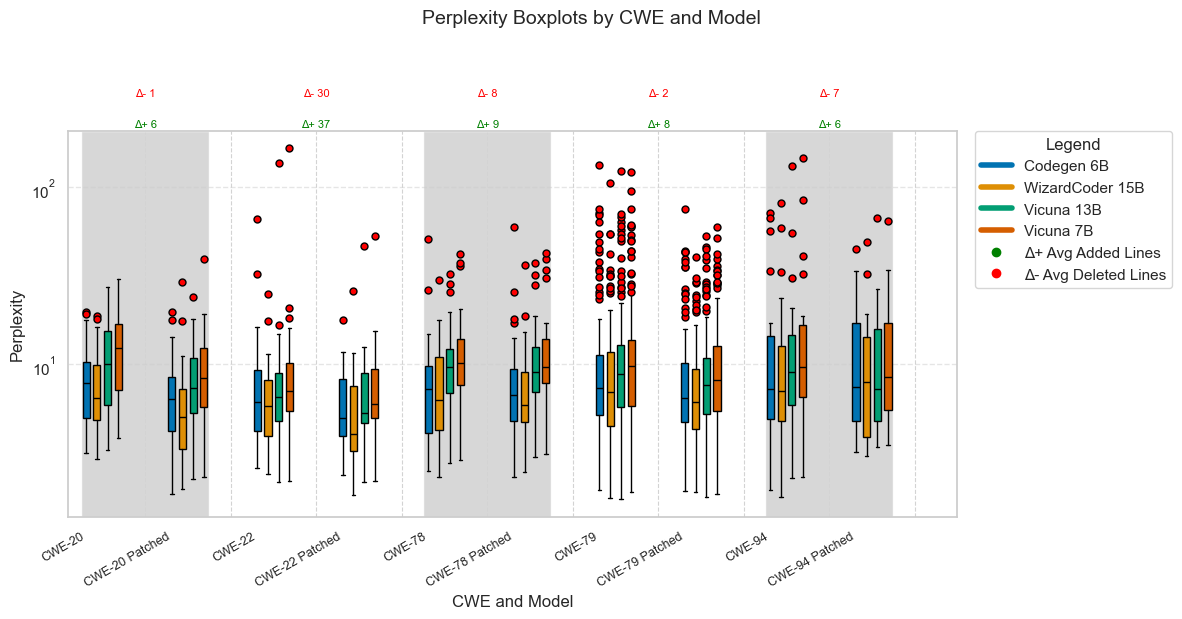

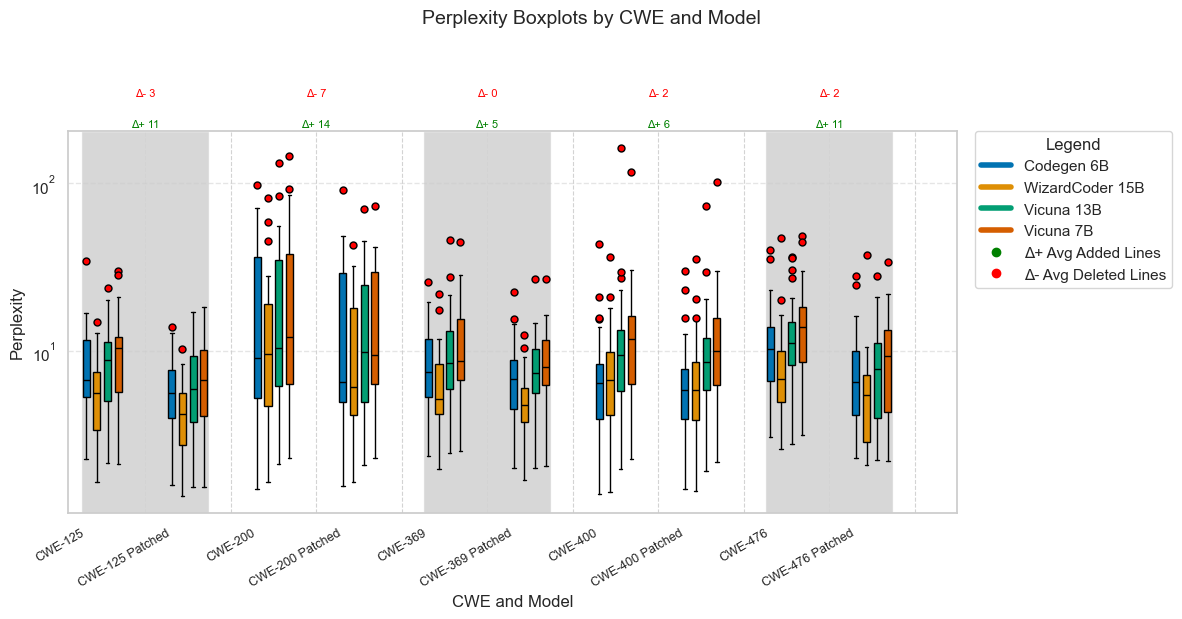

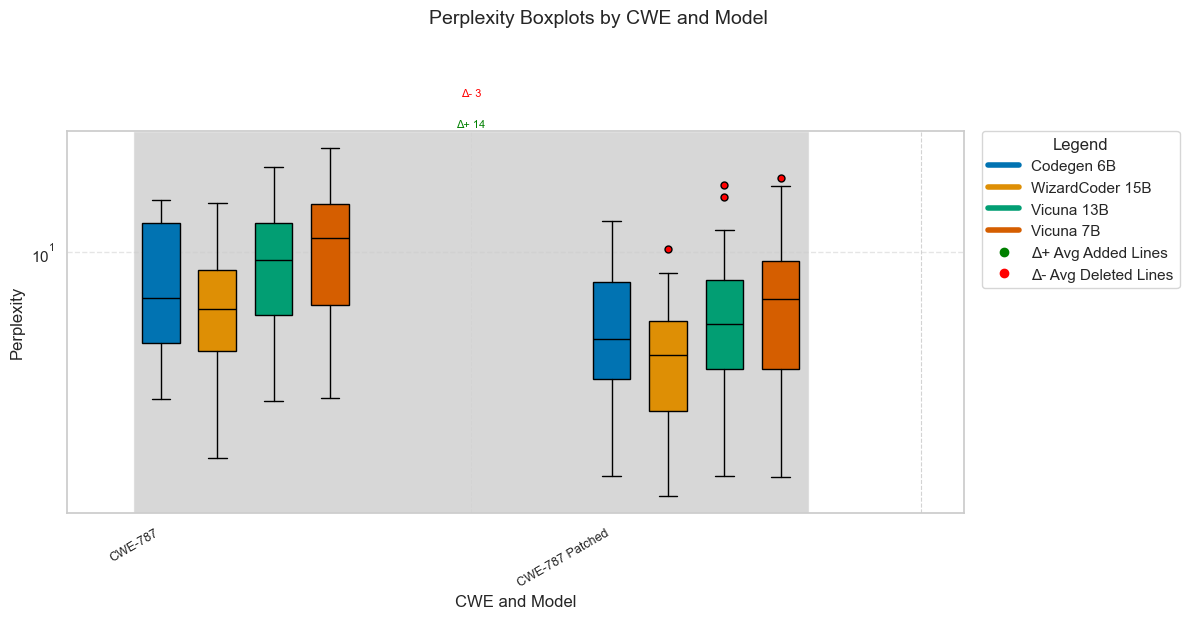

In [141]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")


def plot_grouped_boxplots(df, cwe_subset, model_colors):
    plt.figure(figsize=(12, 6))
    
    # Filter data for selected CWEs
    subset_df = df[df["cwe"].isin(cwe_subset)]
    
    # Sort dataframe by CWE and model
    sorted_df = subset_df.sort_values(by=['cwe', 'model'])
    
    positions = []
    labels = []
    idx = 0
    cwe_spacing = 1.5  # Control spacing between different CWEs
    model_spacing = 0.3  # Control spacing between models under the same CWE

    legend_handles = {}  # To store legend handles
    
    # Grouping by CWE
    for cwe in sorted_df["cwe"].unique():
        cwe_df = sorted_df[sorted_df["cwe"] == cwe]
        cwe_base_idx = idx
        
        for j, model in enumerate(cwe_df["model"].unique()):
            model_df = cwe_df[cwe_df["model"] == model]
            pos = cwe_base_idx + j * model_spacing

            box = plt.boxplot(
                model_df["perplexity"],
                positions=[pos],
                widths=0.2,
                patch_artist=True,
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, markerfacecolor="red"),
            )
            
            # Color the boxes appropriately
            for b in box['boxes']:
                b.set_facecolor(model_colors[model])

            # Store legend info
            if model not in legend_handles:
                legend_handles[model] = plt.Line2D([0], [0], color=model_colors[model], lw=4, label=prettier_names[model])

            if cwe not in labels:
                labels.append(cwe)
            else:
                labels.append("")
            positions.append(pos)
            
        # Update the index to keep CWEs close together
        idx = pos + cwe_spacing
        
        # Optional: draw divider between CWE groups
        plt.axvline(x=idx - (cwe_spacing / 2), color='lightgray', linestyle='--', linewidth=0.8, zorder=0)

        # Get average position of this CWE group to place annotation
        group_positions = [cwe_base_idx + j * model_spacing for j in range(len(cwe_df["model"].unique()))]
        group_center = np.mean(group_positions) + len(cwe_df["model"].unique()) * model_spacing

        # Add annotation (if data is available)
        if cwe in cwe_line_changes:
            change_info = cwe_line_changes[cwe]
            
            plt.annotate(
                f'Δ+ {change_info["added"]}',
                xy=(group_center, 1.01),
                xycoords=('data', 'axes fraction'),
                ha='center', fontsize=8, color='green'
            )
            plt.annotate(
                f'Δ- {change_info["deleted"]}',
                xy=(group_center, 1.09),
                xycoords=('data', 'axes fraction'),
                ha='center', fontsize=8, color='red'
            )
            
            
    for i in range(0, len(positions), len(cwe_df['model'].unique())*4):
        # Highlight background for this CWE group
        plt.axvspan(positions[i] - 1/2*model_spacing,
                    positions[i + len(cwe_df['model'].unique())+2] + 3/2*model_spacing,
                    facecolor='lightgray', alpha=0.9, zorder=0)

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.grid(axis='x', visible=False)

    # Add annotation legend handles (for Δ+ and Δ-)
    annotation_legend = [
        Line2D([0], [0], color='green', lw=0, marker='o', label='Δ+ Avg Added Lines'),
        Line2D([0], [0], color='red', lw=0, marker='o', label='Δ- Avg Deleted Lines')
    ]

    # Combine model and annotation legends
    all_legend_handles = list(legend_handles.values()) + annotation_legend

    # Plot the combined legend
    plt.legend(handles=all_legend_handles, title="Legend", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    # Adjust x-axis labels
    plt.xticks(positions, labels, rotation=30, ha="right", fontsize=9)
    plt.xlabel("CWE and Model")
    plt.ylabel("Perplexity")
    plt.suptitle("Perplexity Boxplots by CWE and Model", y=1.03, fontsize=14)
    #plt.title("Perplexity Boxplots by CWE and Model")
    #plt.legend(handles=legend_handles.values(), title="Models", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    #plt.legend(handles=legend_handles.values(), title="Models")  # Add legend
    plt.tight_layout()
    plt.yscale("log")
    plt.show()

# Get unique CWE values
unique_cwes = df["cwe"].unique()

# Assign colors to models
unique_models = df['model'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_models))
model_colors = {model: palette[i] for i, model in enumerate(unique_models)}

medianprops=dict(color="black", linewidth=2)
whiskerprops=dict(color="gray", linestyle='--', linewidth=1)
capprops=dict(color="gray", linewidth=1)
flierprops=dict(marker="o", markersize=4, markerfacecolor="gray", alpha=0.3)


# Define batch size
batch_size = 10

# Generate plots in batches
for i in range(0, len(unique_cwes), batch_size):
    cwe_batch = unique_cwes[i:i+batch_size]
    plot_grouped_boxplots(df, cwe_batch, model_colors)

In [54]:
cwe_tags = {
    "Injection Flaws": [
        "CWE-77", "CWE-78", "CWE-89", "CWE-94", "CWE-95", "CWE-116",
        "CWE-74", "CWE-79", "CWE-93"
    ],
    "Authentication Issues": [
        "CWE-287", "CWE-306", "CWE-798", "CWE-259",
        "CWE-255", "CWE-290", "CWE-307", "CWE-288", "CWE-294"
    ],
    "Authorization / Access Control": [
        "CWE-284", "CWE-285", "CWE-863", "CWE-732",
        "CWE-264", "CWE-275", "CWE-281", "CWE-639", "CWE-862"
    ],
    "Input Validation": [
        "CWE-20", "CWE-601", "CWE-134", "CWE-643",
        "CWE-129", "CWE-172", "CWE-682", "CWE-704", "CWE-707", "CWE-697"
    ],
    "File Handling": [
        "CWE-22", "CWE-73", "CWE-434", "CWE-97",
        "CWE-59", "CWE-61", "CWE-552"
    ],
    "Memory Management": [
        "CWE-119", "CWE-125", "CWE-787", "CWE-416",
        "CWE-120", "CWE-121", "CWE-122", "CWE-131", "CWE-401", "CWE-415", "CWE-417", "CWE-665", "CWE-667", "CWE-674", "CWE-763", "CWE-772"
    ],
    "Cryptography Issues": [
        "CWE-327", "CWE-328", "CWE-326", "CWE-311",
        "CWE-310", "CWE-320", "CWE-331"
    ],
    "Configuration": [
        "CWE-16", "CWE-250", "CWE-276", "CWE-269",
        "CWE-17", "CWE-19", "CWE-273", "CWE-924"
    ],
    "Error Handling / Logging": [
        "CWE-209", "CWE-248", "CWE-252",
        "CWE-388", "CWE-703", "CWE-704", "CWE-617", "CWE-532"
    ],
    "Information Disclosure": [
        "CWE-200", "CWE-201", "CWE-203",
        "CWE-212", "CWE-522", "CWE-613", "CWE-668", "CWE-918"
    ],
    "Denial of Service": [
        "CWE-400", "CWE-404", "CWE-770",
        "CWE-362", "CWE-369", "CWE-834", "CWE-835", "CWE-672"
    ],
    "Code Quality": [
        "CWE-561", "CWE-398", "CWE-563",
        "CWE-241", "CWE-254", "CWE-345", "CWE-346", "CWE-347", "CWE-354", "CWE-681", "CWE-682", "CWE-706", "CWE-754", "CWE-755"
    ],
    "Race Conditions / Concurrency": [
        "CWE-362", "CWE-361", "CWE-667", "CWE-663", "CWE-662"
    ],
    "Serialization / Deserialization": [
        "CWE-502"
    ],
    "XXE / XML Issues": [
        "CWE-611"
    ],
    "Security Misconfiguration": [
        "CWE-459", "CWE-565", "CWE-843", "CWE-909", "CWE-1021"
    ],
    "Unvalidated Redirects / CSRF": [
        "CWE-352"
    ],
    "Improper Certificate Validation": [
        "CWE-295", "CWE-346", "CWE-347"
    ],
    "Miscellaneous / Logic Issues": [
        "CWE-190", "CWE-191", "CWE-189", "CWE-193", "CWE-706", "CWE-664", "CWE-670", "CWE-843"
    ],
    "Object Injection / Insecure Deserialization": [
        "CWE-502"
    ],
    "Hardcoded Secrets / Weak Passwords": [
        "CWE-259", "CWE-798"
    ],
    "Improper Resource Access or Exposure": [
        "CWE-668", "CWE-552", "CWE-524", "CWE-918"
    ]
}


cwe_tags.setdefault("Authentication Issues", []).append("CWE-294")
cwe_tags.setdefault("Memory Management", []).extend(["CWE-399", "CWE-476", "CWE-824"])
cwe_tags.setdefault("Injection Flaws", []).append("CWE-444")
cwe_tags.setdefault("Resource Management", []).append("CWE-908")

In [55]:
df_cwe_tags = df.copy()
df_cwe_tags["cwe_tag"] = "Other"
# Assign CWE tags
for row in df_cwe_tags.itertuples():
    ends_with_patched = row.cwe.endswith(" Patched")
    row_cwe = row.cwe.split()[0] if row.cwe.endswith(" Patched") else row.cwe
    for tag, cwe_list in cwe_tags.items():
        if row_cwe in cwe_list:
            tag = tag if not ends_with_patched else tag + " Patched"
            df_cwe_tags.at[row.Index, "cwe_tag"] = tag 
            break

print(df_cwe_tags["cwe_tag"].value_counts())    

cwe_tag
Injection Flaws                   12
Injection Flaws Patched           12
Memory Management                 12
Memory Management Patched         12
Denial of Service                  8
Denial of Service Patched          8
Input Validation                   4
Input Validation Patched           4
File Handling                      4
File Handling Patched              4
Information Disclosure             4
Information Disclosure Patched     4
Name: count, dtype: int64


In [56]:
# group by cwe_tag and model
grouped_df = df_cwe_tags.groupby(["cwe_tag", "model"]).agg({
    "perplexity": lambda x: x.tolist()
}).reset_index()
grouped_df["perplexity"] = grouped_df["perplexity"].apply(lambda x: [float(item) for sublist in x for item in sublist if item > 0])

In [57]:
# Compute the IQR
grouped_df["iqr"] = grouped_df["perplexity"].apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# Compute the mean
grouped_df["mean"] = grouped_df["perplexity"].apply(lambda x: np.mean(x))

# Compute the median
grouped_df["median"] = grouped_df["perplexity"].apply(lambda x: np.median(x))

grouped_df

,cwe_tag,model,perplexity,iqr,mean,median
0,Denial of Service,Salesforce/codegen-6B-multi,"[6.80859375, 5.09375, 6.38671875, 5.1328125, 6...",4.791016,8.358690,6.808594
1,Denial of Service,WizardLMTeam/WizardCoder-15B-V1.0,"[6.819545269012451, 4.415157318115234, 5.13764...",5.295023,7.522047,5.715540
2,Denial of Service,lmsys/vicuna-13b-v1.5,"[7.647335529327393, 4.461785316467285, 7.94016...",7.551076,12.590325,9.435597
3,Denial of Service,lmsys/vicuna-7b-v1.5,"[8.417851448059082, 5.078947067260742, 8.68359...",9.529279,13.560065,10.279048
4,Denial of Service Patched,Salesforce/codegen-6B-multi,"[6.0859375, 4.4765625, 6.875, 3.943359375, 4.0...",4.267578,7.251639,6.019531
5,Denial of Service Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[5.588657379150391, 3.7768044471740723, 5.5955...",3.541553,6.404706,5.372232
6,Denial of Service Patched,lmsys/vicuna-13b-v1.5,"[6.466843128204346, 3.7907376289367676, 8.1715...",6.146068,9.717996,7.784186
7,Denial of Service Patched,lmsys/vicuna-7b-v1.5,"[7.401121139526367, 4.429894924163818, 8.13856...",7.300918,11.281853,8.977873
8,File Handling,Salesforce/codegen-6B-multi,"[9.671875, 2.615234375, 7.00390625, 32.28125, ...",5.065430,9.818660,6.123047
9,File Handling,WizardLMTeam/WizardCoder-15B-V1.0,"[8.680630683898926, 2.4744482040405273, 8.8968...",4.216919,6.886187,5.781737


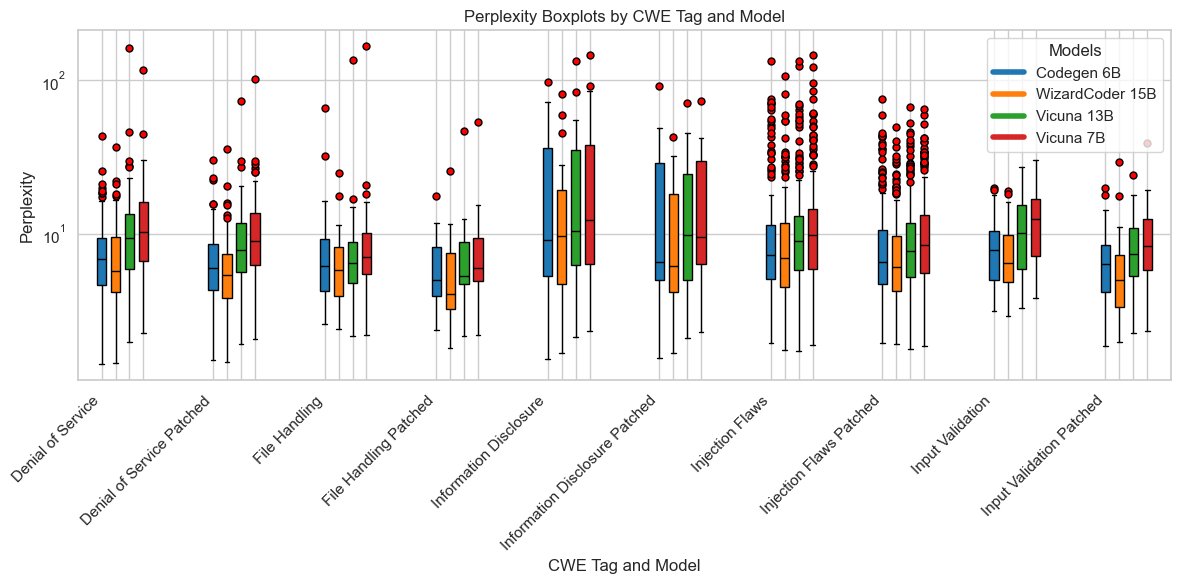

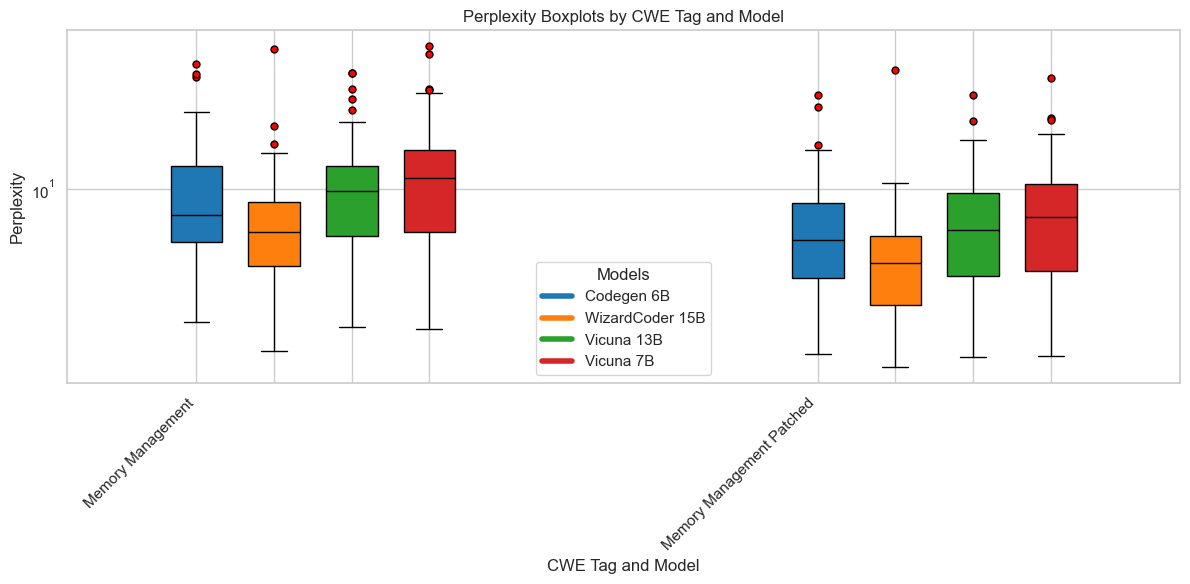

In [58]:
# Plot the grouped boxplots

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")


def plot_grouped_boxplots_tags(df, cwe_subset, model_colors):
    plt.figure(figsize=(12, 6))
    
    # Filter data for selected CWEs
    subset_df = df[df["cwe_tag"].isin(cwe_subset)]
    
    # Sort dataframe by CWE and model
    sorted_df = subset_df.sort_values(by=['cwe_tag', 'model'])
    
    positions = []
    labels = []
    idx = 0
    cwe_spacing = 1.5  # Control spacing between different CWEs
    model_spacing = 0.3  # Control spacing between models under the same CWE

    legend_handles = {}  # To store legend handles
    
    # Grouping by CWE
    for cwe in sorted_df["cwe_tag"].unique():
        cwe_df = sorted_df[sorted_df["cwe_tag"] == cwe]
        cwe_base_idx = idx
        
        for j, model in enumerate(cwe_df["model"].unique()):
            model_df = cwe_df[cwe_df["model"] == model]
            pos = cwe_base_idx + j * model_spacing
            
            # Create boxplot and capture its elements
            box = plt.boxplot(
                model_df["perplexity"],
                positions=[pos],
                widths=0.2,
                patch_artist=True,
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, markerfacecolor="red"),
            )
            
            # Color the boxes appropriately
            for b in box['boxes']:
                b.set_facecolor(model_colors[model])

            # Store legend info
            if model not in legend_handles:
                legend_handles[model] = plt.Line2D([0], [0], color=model_colors[model], lw=4, label=prettier_names[model])

            if cwe not in labels:
                labels.append(cwe)
            else:
                labels.append("")
            positions.append(pos)
            
        # Update the index to keep CWEs close together
        idx = pos + cwe_spacing
    # Adjust x-axis labels
    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.xlabel("CWE Tag and Model")
    plt.ylabel("Perplexity")
    plt.title("Perplexity Boxplots by CWE Tag and Model")
    plt.legend(handles=legend_handles.values(), title="Models")  # Add legend
    plt.tight_layout()
    plt.yscale("log")
    plt.show()

# Get unique CWE values
unique_cwes = grouped_df["cwe_tag"].unique()

# Assign colors to models
unique_models = grouped_df['model'].unique()
model_colors = {model: plt.cm.tab10(i % 10) for i, model in enumerate(unique_models)}

# Define batch size
batch_size = 10

# Generate plots in batches
for i in range(0, len(unique_cwes), batch_size):
    cwe_batch = unique_cwes[i:i+batch_size]
    plot_grouped_boxplots_tags(grouped_df, cwe_batch, model_colors)

In [42]:
# See the value of the "other" tag

df_sub = grouped_df[(grouped_df['model'] == "Salesforce/codegen-6B-multi") & (grouped_df['patched'] == True)]
df_sub[df_sub['cwe_tag'] == "Other"]

,cwe_tag,model,perplexity,iqr,mean,median,base_cwe,patched


In [43]:
# Remove the "Other" tag from grouped_df
grouped_df = grouped_df[grouped_df["cwe_tag"] != "Other"]

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_48826/3811370302.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_df['base_cwe'] = grouped_df['cwe_tag'].str.replace(' Patched', '', regex=False)
/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_48826/3811370302.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_df['patched'] = grouped_df['cwe_tag'].str.contains('Patched')


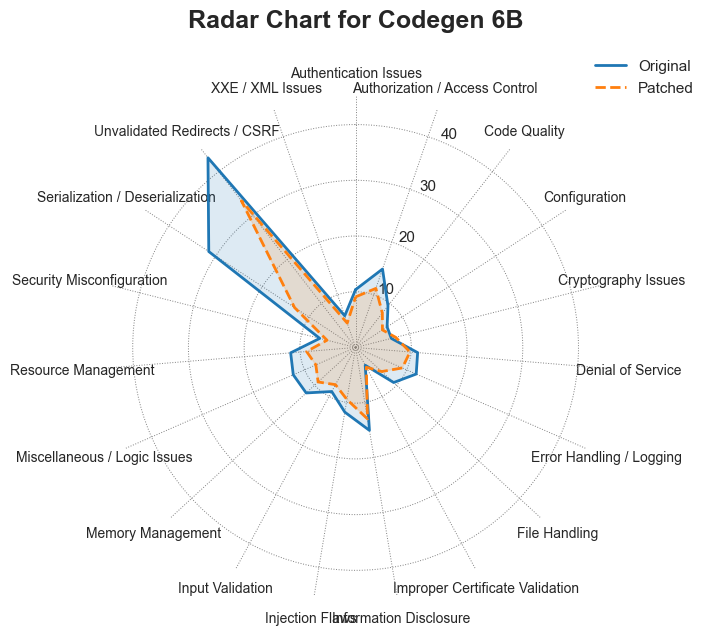

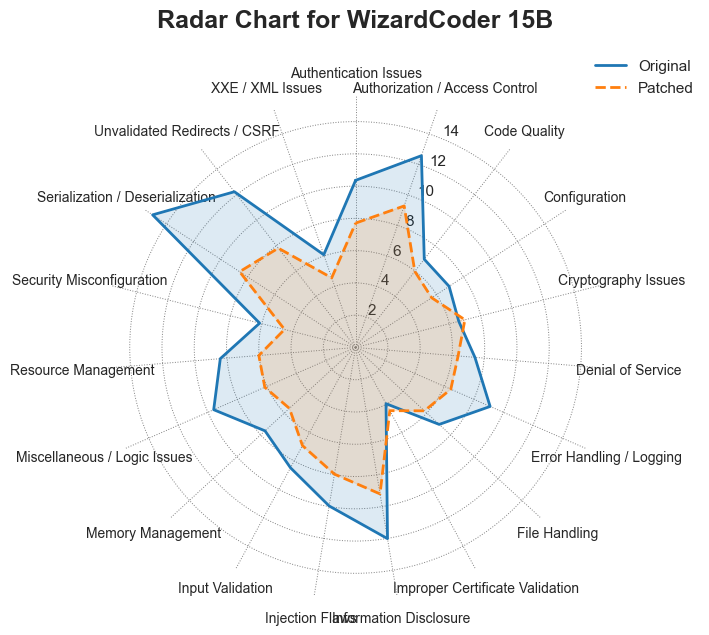

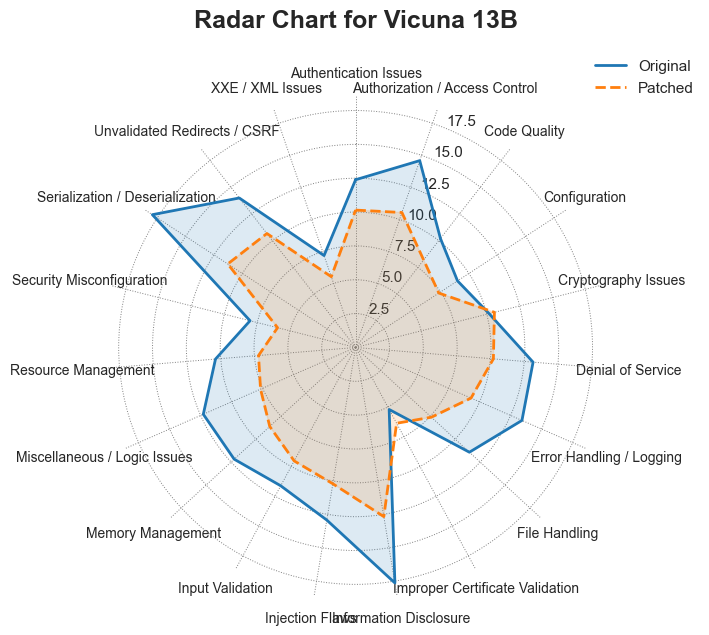

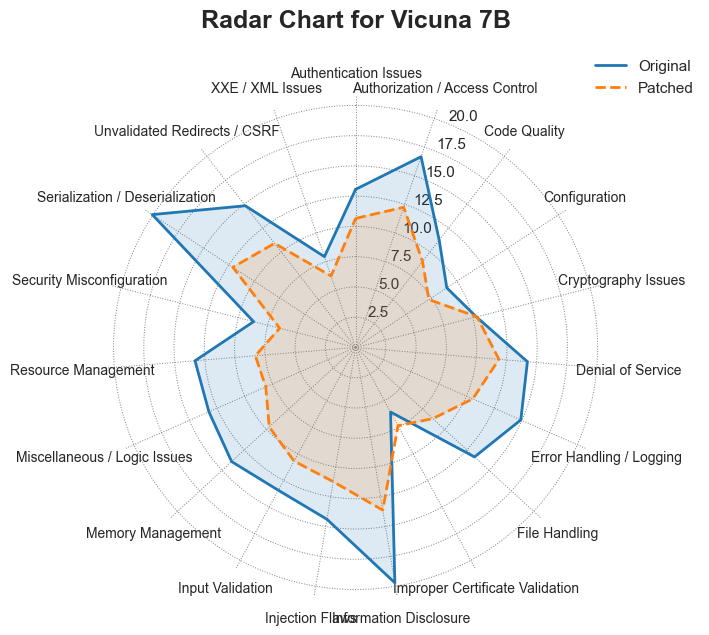

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize CWE tags
grouped_df['base_cwe'] = grouped_df['cwe_tag'].str.replace(' Patched', '', regex=False)
grouped_df['patched'] = grouped_df['cwe_tag'].str.contains('Patched')

# Base tags and models
base_tags = grouped_df['base_cwe'].unique()
models = grouped_df['model'].unique()

# Radar chart setup
num_vars = len(base_tags)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Style settings
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 18,
    'legend.fontsize': 11,
})

# Color palette
colors = {
    'Original': '#1f77b4',  # Blue
    'Patched': '#ff7f0e'    # Orange
}

# Create radar chart for each model
figures = []
for model in models:
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for is_patched, style in zip([False, True], ['solid', 'dashed']):
        label = 'Patched' if is_patched else 'Original'
        df_sub = grouped_df[(grouped_df['model'] == model) & (grouped_df['patched'] == is_patched)]
        values = df_sub.set_index('base_cwe').reindex(base_tags)['mean'].tolist()
        values += values[:1]
        
        ax.plot(angles, values, linestyle=style, linewidth=2, label=label, color=colors[label])
        ax.fill(angles, values, alpha=0.15, color=colors[label])
    
    # Aesthetics
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(base_tags, fontsize=10)

    # Rotate each xtick label to avoid overlap
    for label, angle in zip(ax.get_xticklabels(), angles):
        label.set_rotation(np.degrees(angle))
        label.set_horizontalalignment('center')
    
    ax.set_title(f'Radar Chart for {prettier_names[model]}', y=1.12, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), frameon=False)
    ax.spines['polar'].set_visible(False)
    ax.grid(color='gray', linestyle='dotted', linewidth=0.7)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    plt.tight_layout(pad=3)

    figures.append(fig)

plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Normalize CWE tags
# grouped_df['base_cwe'] = grouped_df['cwe_tag'].str.replace(' Patched', '', regex=False)
# grouped_df['patched'] = grouped_df['cwe_tag'].str.contains('Patched')

# # Base tags and models
# base_tags = grouped_df['base_cwe'].unique()
# models = grouped_df['model'].unique()

# # Radar chart setup
# num_vars = len(base_tags)
# angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
# angles += angles[:1]

# # Style settings
# plt.rcParams.update({
#     'font.size': 11,
#     'axes.titlesize': 18,
#     'legend.fontsize': 11,
# })

# # Color palette for models
# color_map = plt.get_cmap("tab10")
# model_colors = {model: color_map(i) for i, model in enumerate(models)}

# # Create one radar chart for each patch status
# for is_patched, patch_label in zip([False, True], ['Original', 'Patched']):
#     fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
#     for model in models:
#         df_sub = grouped_df[(grouped_df['model'] == model) & (grouped_df['patched'] == is_patched)]
#         values = df_sub.set_index('base_cwe').reindex(base_tags)['mean'].tolist()
#         values += values[:1]
        
#         ax.plot(angles, values, linewidth=2, label=prettier_names[model], color=model_colors[model])
#         ax.fill(angles, values, alpha=0.15, color=model_colors[model])
    
#     # Aesthetics
#     ax.set_xticks(angles[:-1])
#     ax.set_xticklabels(base_tags, fontsize=10)

#     # Rotate labels
#     for label, angle in zip(ax.get_xticklabels(), angles):
#         label.set_rotation(np.degrees(angle))
#         label.set_horizontalalignment('center')

#     ax.set_title(f'{patch_label} Vulnerabilities Across Models', y=1.12, fontweight='bold')
#     ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), frameon=False)
#     ax.spines['polar'].set_visible(False)
#     ax.grid(color='gray', linestyle='dotted', linewidth=0.7)
#     ax.set_theta_offset(np.pi / 2)
#     ax.set_theta_direction(-1)
#     #ax.set_ylim(0, 6)  # or whatever makes sense based on your data range
#     plt.tight_layout(pad=3)
#     plt.show()
